In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
wego = pd.read_csv('./data/headway_data_20230801-20230930_w_ca_edits.csv')

4. How much of a factor does the driver have on on-time performance? The driver is indicated by the OPERATOR variable.

Compare ADHERENCE and ADJUSTED percentages for early, late and on-time.

In [3]:
wego_filtered = wego[['OPERATOR','ADHERENCE','ADJUSTED_EARLY_COUNT','ADJUSTED_LATE_COUNT','ADJUSTED_ONTIME_COUNT']]

In [4]:
wego_filtered

,OPERATOR,ADHERENCE,ADJUSTED_EARLY_COUNT,ADJUSTED_LATE_COUNT,ADJUSTED_ONTIME_COUNT
0,0,8.92,0,0,1
1,56,-2.90,0,0,1
2,56,-0.63,0,0,1
3,56,0.12,0,0,1
4,235,3.30,1,0,0
...,...,...,...,...,...
350324,3173,-1.65,0,0,1
350325,3173,-1.45,0,0,1
350326,3173,-2.67,0,0,1
350327,3173,-1.03,0,0,1


In [5]:
wego_filtered = wego_filtered[~wego_filtered['ADHERENCE'].isna() == True]

In [6]:
wego_filtered

,OPERATOR,ADHERENCE,ADJUSTED_EARLY_COUNT,ADJUSTED_LATE_COUNT,ADJUSTED_ONTIME_COUNT
0,0,8.92,0,0,1
1,56,-2.90,0,0,1
2,56,-0.63,0,0,1
3,56,0.12,0,0,1
4,235,3.30,1,0,0
...,...,...,...,...,...
350324,3173,-1.65,0,0,1
350325,3173,-1.45,0,0,1
350326,3173,-2.67,0,0,1
350327,3173,-1.03,0,0,1


In [7]:
operator_adherence = wego_filtered.groupby('OPERATOR')['ADHERENCE'].mean().sort_values().to_frame().reset_index()

In [8]:
operator_adherence

,OPERATOR,ADHERENCE
0,473,-22.070000
1,2530,-16.606471
2,2982,-14.234286
3,3101,-11.131773
4,1016,-10.519855
...,...,...
336,1606,1.124118
337,1762,1.168200
338,1761,1.298180
339,2646,2.395143


In [9]:
operator_adherence.head(10)

,OPERATOR,ADHERENCE
0,473,-22.070000
1,2530,-16.606471
2,2982,-14.234286
3,3101,-11.131773
4,1016,-10.519855
5,1880,-9.765263
6,2137,-9.382381
7,2400,-9.353846
8,3098,-9.131335
9,3096,-9.082834


In [10]:
operator_adherence.tail(10)

,OPERATOR,ADHERENCE
331,2103,0.268034
332,1730,0.390121
333,2639,0.462754
334,1170,0.533269
335,465,1.118889
336,1606,1.124118
337,1762,1.168200
338,1761,1.298180
339,2646,2.395143
340,0,8.920000


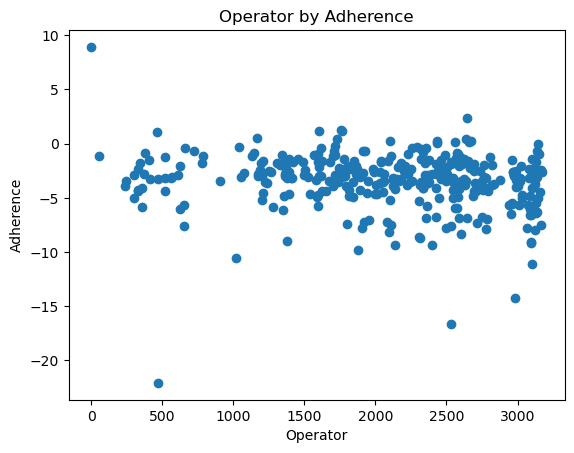

In [11]:
x = operator_adherence['OPERATOR']
y = operator_adherence['ADHERENCE']
plt.scatter(x,y)
plt.title("Operator by Adherence")
plt.xlabel("Operator")
plt.ylabel("Adherence")
plt.show()

In [12]:
operator_adherence.sort_values(by='ADHERENCE', ascending=False).head(10)

,OPERATOR,ADHERENCE
340,0,8.920000
339,2646,2.395143
338,1761,1.298180
337,1762,1.168200
336,1606,1.124118
335,465,1.118889
334,1170,0.533269
333,2639,0.462754
332,1730,0.390121
331,2103,0.268034


In [13]:
operator_adherence.sort_values(by='ADHERENCE', ascending=False).tail(10)

,OPERATOR,ADHERENCE
9,3096,-9.082834
8,3098,-9.131335
7,2400,-9.353846
6,2137,-9.382381
5,1880,-9.765263
4,1016,-10.519855
3,3101,-11.131773
2,2982,-14.234286
1,2530,-16.606471
0,473,-22.070000


In [14]:
operator_adherence.corr()

,OPERATOR,ADHERENCE
OPERATOR,1.000000,-0.144613
ADHERENCE,-0.144613,1.000000


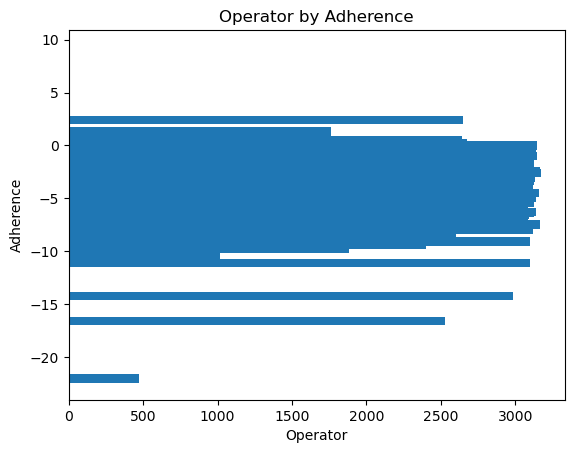

In [15]:
plt.barh(operator_adherence['ADHERENCE'], operator_adherence['OPERATOR'])
plt.title("Operator by Adherence")
plt.xlabel("Operator")
plt.ylabel("Adherence")
plt.show()

In [16]:
operator_adherence_head = wego_filtered.groupby('OPERATOR')['ADHERENCE'].mean().sort_values().head(10).to_frame().reset_index()

In [17]:
operator_adherence_head

,OPERATOR,ADHERENCE
0,473,-22.070000
1,2530,-16.606471
2,2982,-14.234286
3,3101,-11.131773
4,1016,-10.519855
5,1880,-9.765263
6,2137,-9.382381
7,2400,-9.353846
8,3098,-9.131335
9,3096,-9.082834


In [18]:
operator_adherence_tail = wego_filtered.groupby('OPERATOR')['ADHERENCE'].mean().sort_values().tail(10).to_frame().reset_index()

In [19]:
operator_adherence_tail

,OPERATOR,ADHERENCE
0,2103,0.268034
1,1730,0.390121
2,2639,0.462754
3,1170,0.533269
4,465,1.118889
5,1606,1.124118
6,1762,1.168200
7,1761,1.298180
8,2646,2.395143
9,0,8.920000


In [20]:
operator_adjusted = wego_filtered.groupby('OPERATOR')[['ADJUSTED_EARLY_COUNT','ADJUSTED_LATE_COUNT','ADJUSTED_ONTIME_COUNT']].sum().reset_index()

In [21]:
operator_adjusted

,OPERATOR,ADJUSTED_EARLY_COUNT,ADJUSTED_LATE_COUNT,ADJUSTED_ONTIME_COUNT
0,0,0,0,1
1,56,0,0,3
2,235,1,5,6
3,244,0,5,20
4,301,1,17,19
...,...,...,...,...
336,3149,4,8,76
337,3156,0,71,219
338,3165,0,20,12
339,3166,0,3,32


In [22]:
operator_adjusted['TOTAL'] = operator_adjusted['ADJUSTED_EARLY_COUNT'] +  operator_adjusted['ADJUSTED_LATE_COUNT'] + operator_adjusted['ADJUSTED_ONTIME_COUNT']

In [23]:
operator_adjusted['EARLY_PCT'] = round(operator_adjusted['ADJUSTED_EARLY_COUNT'] / operator_adjusted['TOTAL'] * 100,2)

In [24]:
operator_adjusted['EARLY_PCT'].head(10)

0    0.00
1    0.00
2    8.33
3    0.00
4    2.70
5    0.12
6    2.12
7    1.71
8    2.26
9    4.26
Name: EARLY_PCT, dtype: float64

In [25]:
operator_adjusted['LATE_PCT'] = round(operator_adjusted['ADJUSTED_LATE_COUNT'] / operator_adjusted['TOTAL'] * 100,2)

In [26]:
operator_adjusted['LATE_PCT'].head(10)

0     0.00
1     0.00
2    41.67
3    20.00
4    45.95
5    11.30
6    22.78
7    12.89
8    21.66
9     9.29
Name: LATE_PCT, dtype: float64

In [27]:
operator_adjusted['ONTIME_PCT'] = round(operator_adjusted['ADJUSTED_ONTIME_COUNT'] / operator_adjusted['TOTAL'] * 100,2)

In [28]:
operator_adjusted['ONTIME_PCT']

0      100.00
1      100.00
2       50.00
3       80.00
4       51.35
        ...  
336     86.36
337     75.52
338     37.50
339     91.43
340     90.91
Name: ONTIME_PCT, Length: 341, dtype: float64

In [29]:
operator_adjusted

,OPERATOR,ADJUSTED_EARLY_COUNT,ADJUSTED_LATE_COUNT,ADJUSTED_ONTIME_COUNT,TOTAL,EARLY_PCT,LATE_PCT,ONTIME_PCT
0,0,0,0,1,1,0.00,0.00,100.00
1,56,0,0,3,3,0.00,0.00,100.00
2,235,1,5,6,12,8.33,41.67,50.00
3,244,0,5,20,25,0.00,20.00,80.00
4,301,1,17,19,37,2.70,45.95,51.35
...,...,...,...,...,...,...,...,...
336,3149,4,8,76,88,4.55,9.09,86.36
337,3156,0,71,219,290,0.00,24.48,75.52
338,3165,0,20,12,32,0.00,62.50,37.50
339,3166,0,3,32,35,0.00,8.57,91.43


In [30]:
operator_adjusted.corr()

,OPERATOR,ADJUSTED_EARLY_COUNT,ADJUSTED_LATE_COUNT,ADJUSTED_ONTIME_COUNT,TOTAL,EARLY_PCT,LATE_PCT,ONTIME_PCT
OPERATOR,1.000000,-0.068767,0.003199,-0.271178,-0.233310,0.040423,0.099761,-0.112798
ADJUSTED_EARLY_COUNT,-0.068767,1.000000,0.063648,0.392851,0.405454,0.548909,-0.243141,0.095379
ADJUSTED_LATE_COUNT,0.003199,0.063648,1.000000,0.440691,0.617347,-0.210474,0.350185,-0.298241
ADJUSTED_ONTIME_COUNT,-0.271178,0.392851,0.440691,1.000000,0.976711,-0.125207,-0.328419,0.369155
TOTAL,-0.233310,0.405454,0.617347,0.976711,1.000000,-0.125571,-0.208626,0.247266
EARLY_PCT,0.040423,0.548909,-0.210474,-0.125207,-0.125571,1.000000,-0.201653,-0.071962
LATE_PCT,0.099761,-0.243141,0.350185,-0.328419,-0.208626,-0.201653,1.000000,-0.962406
ONTIME_PCT,-0.112798,0.095379,-0.298241,0.369155,0.247266,-0.071962,-0.962406,1.000000


In [31]:
operator_adjusted_early = operator_adjusted.sort_values(by='EARLY_PCT', ascending=False).head(10)

In [32]:
operator_adjusted_early

,OPERATOR,ADJUSTED_EARLY_COUNT,ADJUSTED_LATE_COUNT,ADJUSTED_ONTIME_COUNT,TOTAL,EARLY_PCT,LATE_PCT,ONTIME_PCT
16,465,6,0,12,18,33.33,0.00,66.67
102,1730,181,20,460,661,27.38,3.03,69.59
88,1606,4,0,13,17,23.53,0.00,76.47
29,659,379,44,1492,1915,19.79,2.30,77.91
177,2256,1,0,5,6,16.67,0.00,83.33
323,3118,4,6,14,24,16.67,25.00,58.33
231,2563,70,14,359,443,15.80,3.16,81.04
87,1603,86,32,433,551,15.61,5.81,78.58
310,3080,4,4,18,26,15.38,15.38,69.23
157,2112,234,136,1199,1569,14.91,8.67,76.42


In [33]:
operator_adjusted_early.corr()

,OPERATOR,ADJUSTED_EARLY_COUNT,ADJUSTED_LATE_COUNT,ADJUSTED_ONTIME_COUNT,TOTAL,EARLY_PCT,LATE_PCT,ONTIME_PCT
OPERATOR,1.000000,-0.430068,-0.066193,-0.373953,-0.372948,-0.680213,0.702796,-0.191245
ADJUSTED_EARLY_COUNT,-0.430068,1.000000,0.644407,0.970212,0.974400,-0.063109,-0.191761,0.255431
ADJUSTED_LATE_COUNT,-0.066193,0.644407,1.000000,0.769689,0.774619,-0.328688,0.052939,0.212361
ADJUSTED_ONTIME_COUNT,-0.373953,0.970212,0.769689,1.000000,0.999394,-0.199021,-0.149850,0.321935
TOTAL,-0.372948,0.974400,0.774619,0.999394,1.000000,-0.185257,-0.148297,0.309040
EARLY_PCT,-0.680213,-0.063109,-0.328688,-0.199021,-0.185257,1.000000,-0.458901,-0.329267
LATE_PCT,0.702796,-0.191761,0.052939,-0.149850,-0.148297,-0.458901,1.000000,-0.687842
ONTIME_PCT,-0.191245,0.255431,0.212361,0.321935,0.309040,-0.329267,-0.687842,1.000000


In [34]:
operator_adjusted_late = operator_adjusted.sort_values(by='LATE_PCT', ascending=False).head(10)

In [35]:
operator_adjusted_late

,OPERATOR,ADJUSTED_EARLY_COUNT,ADJUSTED_LATE_COUNT,ADJUSTED_ONTIME_COUNT,TOTAL,EARLY_PCT,LATE_PCT,ONTIME_PCT
28,656,0,1,0,1,0.00,100.00,0.00
18,473,0,1,0,1,0.00,100.00,0.00
294,2982,0,26,2,28,0.00,92.86,7.14
64,1377,0,48,12,60,0.00,80.00,20.00
153,2094,5,24,9,38,13.16,63.16,23.68
34,1016,0,87,51,138,0.00,63.04,36.96
338,3165,0,20,12,32,0.00,62.50,37.50
316,3098,7,251,199,457,1.53,54.92,43.54
181,2312,16,714,582,1312,1.22,54.42,44.36
319,3101,19,699,579,1297,1.46,53.89,44.64


In [36]:
operator_adjusted_ontime = operator_adjusted.sort_values(by='ONTIME_PCT', ascending=False).head(10)

In [37]:
operator_adjusted_ontime

,OPERATOR,ADJUSTED_EARLY_COUNT,ADJUSTED_LATE_COUNT,ADJUSTED_ONTIME_COUNT,TOTAL,EARLY_PCT,LATE_PCT,ONTIME_PCT
0,0,0,0,1,1,0.00,0.00,100.00
1,56,0,0,3,3,0.00,0.00,100.00
178,2294,0,0,45,45,0.00,0.00,100.00
107,1762,16,23,2294,2333,0.69,0.99,98.33
98,1706,1,0,43,44,2.27,0.00,97.73
84,1597,0,6,252,258,0.00,2.33,97.67
251,2639,3,2,202,207,1.45,0.97,97.58
234,2573,0,12,400,412,0.00,2.91,97.09
14,409,9,61,2310,2380,0.38,2.56,97.06
79,1566,17,48,2135,2200,0.77,2.18,97.05


In [38]:
operator_adjusted

,OPERATOR,ADJUSTED_EARLY_COUNT,ADJUSTED_LATE_COUNT,ADJUSTED_ONTIME_COUNT,TOTAL,EARLY_PCT,LATE_PCT,ONTIME_PCT
0,0,0,0,1,1,0.00,0.00,100.00
1,56,0,0,3,3,0.00,0.00,100.00
2,235,1,5,6,12,8.33,41.67,50.00
3,244,0,5,20,25,0.00,20.00,80.00
4,301,1,17,19,37,2.70,45.95,51.35
...,...,...,...,...,...,...,...,...
336,3149,4,8,76,88,4.55,9.09,86.36
337,3156,0,71,219,290,0.00,24.48,75.52
338,3165,0,20,12,32,0.00,62.50,37.50
339,3166,0,3,32,35,0.00,8.57,91.43


In [39]:
df = operator_adjusted.sort_values('ONTIME_PCT', ascending=False).head(10)

In [40]:
df = df[['OPERATOR','EARLY_PCT','LATE_PCT','ONTIME_PCT']]

In [41]:
df.set_index('OPERATOR', inplace=True)

In [42]:
df

,EARLY_PCT,LATE_PCT,ONTIME_PCT
OPERATOR,,,
0,0.00,0.00,100.00
56,0.00,0.00,100.00
2294,0.00,0.00,100.00
1762,0.69,0.99,98.33
1706,2.27,0.00,97.73
1597,0.00,2.33,97.67
2639,1.45,0.97,97.58
2573,0.00,2.91,97.09
409,0.38,2.56,97.06


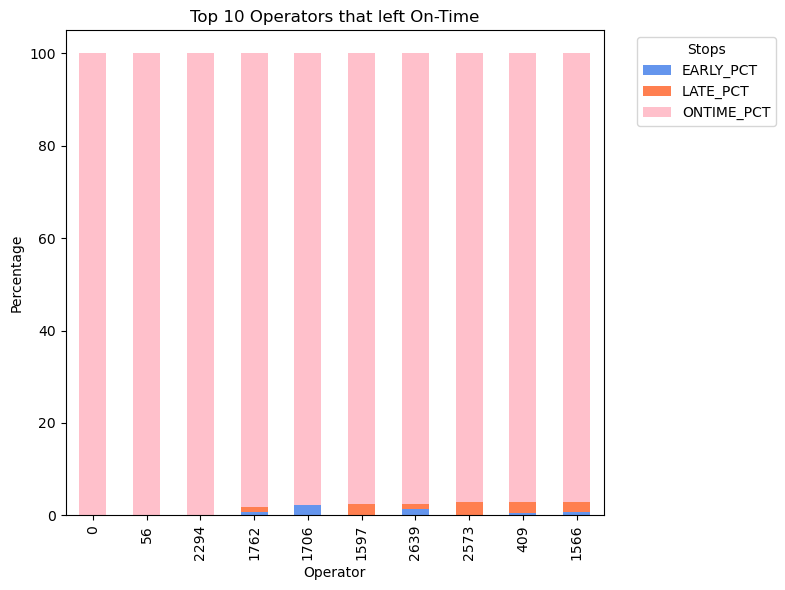

In [43]:
df.plot(
    kind='bar',
    stacked=True,
    figsize=(8, 6),
    color = ['cornflowerblue', 'coral', 'pink']
)

plt.title('Top 10 Operators that left On-Time')
plt.xlabel('Operator')
plt.ylabel('Percentage')
plt.legend(title='Stops', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.savefig('./Filename.png', bbox_inches='tight', pad_inches=0.1)
plt.tight_layout()
plt.show()

In [44]:
operator_adjusted.corr()

,OPERATOR,ADJUSTED_EARLY_COUNT,ADJUSTED_LATE_COUNT,ADJUSTED_ONTIME_COUNT,TOTAL,EARLY_PCT,LATE_PCT,ONTIME_PCT
OPERATOR,1.000000,-0.068767,0.003199,-0.271178,-0.233310,0.040423,0.099761,-0.112798
ADJUSTED_EARLY_COUNT,-0.068767,1.000000,0.063648,0.392851,0.405454,0.548909,-0.243141,0.095379
ADJUSTED_LATE_COUNT,0.003199,0.063648,1.000000,0.440691,0.617347,-0.210474,0.350185,-0.298241
ADJUSTED_ONTIME_COUNT,-0.271178,0.392851,0.440691,1.000000,0.976711,-0.125207,-0.328419,0.369155
TOTAL,-0.233310,0.405454,0.617347,0.976711,1.000000,-0.125571,-0.208626,0.247266
EARLY_PCT,0.040423,0.548909,-0.210474,-0.125207,-0.125571,1.000000,-0.201653,-0.071962
LATE_PCT,0.099761,-0.243141,0.350185,-0.328419,-0.208626,-0.201653,1.000000,-0.962406
ONTIME_PCT,-0.112798,0.095379,-0.298241,0.369155,0.247266,-0.071962,-0.962406,1.000000


In [45]:
df_e = operator_adjusted.sort_values('EARLY_PCT', ascending=False).head(10)

In [46]:
df_early = df_e[['OPERATOR','EARLY_PCT','LATE_PCT','ONTIME_PCT']]

In [47]:
df_early.set_index('OPERATOR', inplace=True)

In [48]:
df_early

,EARLY_PCT,LATE_PCT,ONTIME_PCT
OPERATOR,,,
465,33.33,0.00,66.67
1730,27.38,3.03,69.59
1606,23.53,0.00,76.47
659,19.79,2.30,77.91
2256,16.67,0.00,83.33
3118,16.67,25.00,58.33
2563,15.80,3.16,81.04
1603,15.61,5.81,78.58
3080,15.38,15.38,69.23


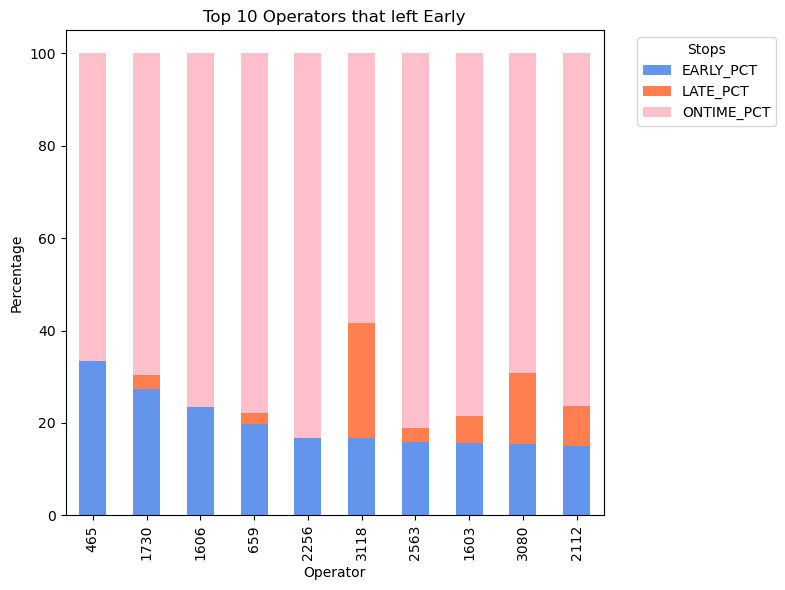

In [49]:
df_early.plot(
    kind='bar',
    stacked=True,
    figsize=(8, 6),
    color = ['cornflowerblue', 'coral', 'pink']
)

plt.title('Top 10 Operators that left Early')
plt.xlabel('Operator')
plt.ylabel('Percentage')
plt.legend(title='Stops', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.savefig('./Filename.png', bbox_inches='tight', pad_inches=0.1)
plt.tight_layout()
plt.show()

In [50]:
df_l = operator_adjusted.sort_values('LATE_PCT', ascending=False).head(10)

In [51]:
df_late = df_l[['OPERATOR','EARLY_PCT','LATE_PCT','ONTIME_PCT']]

In [52]:
df_late.set_index('OPERATOR', inplace=True)

In [53]:
df_late

,EARLY_PCT,LATE_PCT,ONTIME_PCT
OPERATOR,,,
656,0.00,100.00,0.00
473,0.00,100.00,0.00
2982,0.00,92.86,7.14
1377,0.00,80.00,20.00
2094,13.16,63.16,23.68
1016,0.00,63.04,36.96
3165,0.00,62.50,37.50
3098,1.53,54.92,43.54
2312,1.22,54.42,44.36


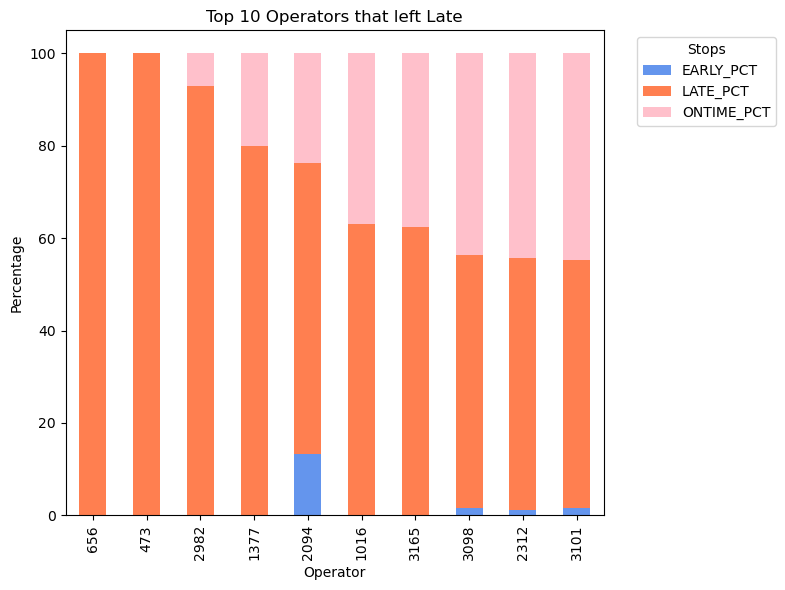

In [54]:
df_late.plot(
    kind='bar',
    stacked=True,
    figsize=(8, 6),
    color = ['cornflowerblue', 'coral', 'pink']
)

plt.title('Top 10 Operators that left Late')
plt.xlabel('Operator')
plt.ylabel('Percentage')
plt.legend(title='Stops', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.savefig('./Filename.png', bbox_inches='tight', pad_inches=0.1)
plt.tight_layout()
plt.show()